In [3]:
import pandas as pd
import numpy as np

n=300

data=pd.DataFrame({
    "age":np.random.randint(18,60,n),
    "salary":np.random.randint(20000,100000,n),
    "balance":np.random.randint(0,200000,n)
})

data["churn"] = (
    (data["balance"] > 100000) |
    (data["salary"] < 40000)
).astype(int)

data.head()

,age,salary,balance,churn
0,34,89017,189370,1
1,31,73843,123916,1
2,35,21152,119489,1
3,55,84730,57563,0
4,49,91089,107895,1


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report,roc_auc_score,roc_curve

In [8]:
from pandas.core.api import RangeIndex
print(data.shape)
print(data.info)
print(data.describe())

print(data["churn"].vaue_counts())


(300, 4)
<bound method DataFrame.info of      age  salary  balance  churn
0     34   89017   189370      1
1     31   73843   123916      1
2     35   21152   119489      1
3     55   84730    57563      0
4     49   91089   107895      1
..   ...     ...      ...    ...
295   54   99421    21945      0
296   46   73458    95897      0
297   52   24950   102013      1
298   59   67758   137620      1
299   52   33940   190838      1

[300 rows x 4 columns]>
              age        salary        balance       churn
count  300.000000    300.000000     300.000000  300.000000
mean    38.466667  58756.973333   97113.506667    0.593333
std     12.034881  23147.172760   58585.875781    0.492032
min     18.000000  20013.000000     823.000000    0.000000
25%     28.000000  38816.500000   48050.250000    0.000000
50%     39.000000  59029.000000   95661.000000    1.000000
75%     48.000000  80004.250000  149298.250000    1.000000
max     59.000000  99463.000000  199773.000000    1.000000


AttributeError: 'Series' object has no attribute 'vaue_counts'

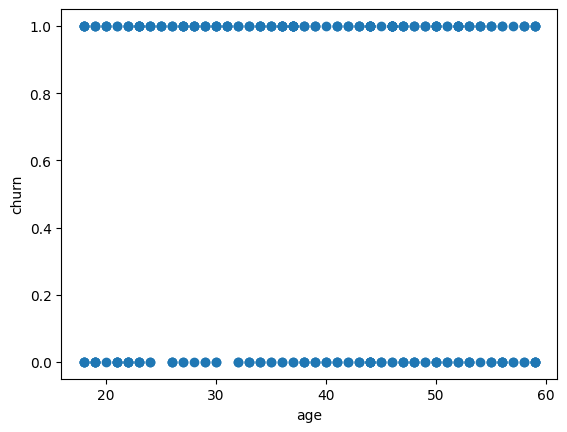

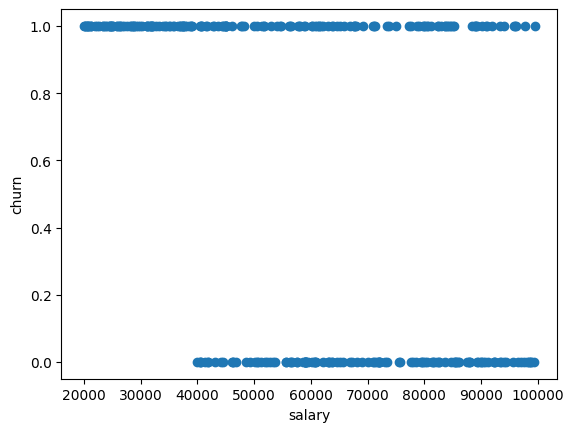

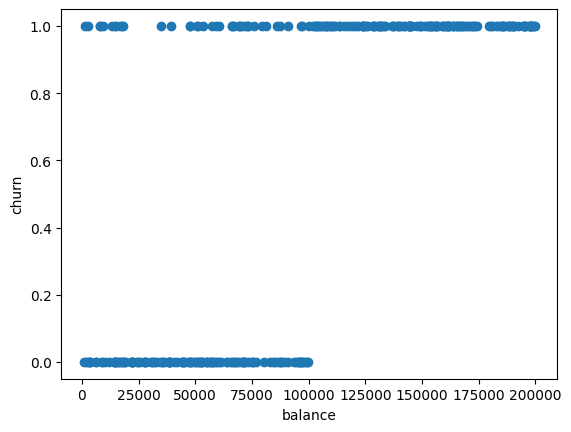

In [10]:
features=["age","salary","balance"]

for col in features:
    plt.figure()
    plt.scatter(data[col],data["churn"])
    plt.xlabel(col)
    plt.ylabel("churn")
    plt.show()

In [20]:
# This cell is no longer needed as its content has been merged into cell wMP3syaS3xVL.

In [16]:
# This cell is no longer needed as its content has been merged into cell wMP3syaS3xVL.

In [19]:
x=data[["age","salary","balance"]]
y=data["churn"]
x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.2,random_state=42
)

In [21]:
model=LogisticRegression(max_iter=1000)
model.fit(x_train,y_train)

LogisticRegression(max_iter=1000)

In [22]:
y_pred=model.predict(x_test)
y_prob=model.predict_proba(x_test)[:,1]

In [24]:
print("accuracy:",accuracy_score(y_test,y_pred))
print("confusion matrix:\n",confusion_matrix(y_test,y_pred))
print("classification report:\n",classification_report(y_test,y_pred))
print("roc auc score:",roc_auc_score(y_test,y_prob))

accuracy: 0.9
confusion matrix:
 [[23  2]
 [ 4 31]]
classification report:
               precision    recall  f1-score   support

           0       0.85      0.92      0.88        25
           1       0.94      0.89      0.91        35

    accuracy                           0.90        60
   macro avg       0.90      0.90      0.90        60
weighted avg       0.90      0.90      0.90        60

roc auc score: 0.9474285714285715


In [27]:
coeff_df=pd.DataFrame({
    "feature":x.columns,
    "coefficient":model.coef_[0]
})

print(coeff_df)

   feature  coefficient
0      age     0.067366
1   salary    -0.000106
2  balance     0.000062


In [28]:
new_data=pd.DataFrame({
    "age":[35],
    "salary":[30000],
    "balance":[150000]
})
print("churn predicition:",model.predict(new_data)[0])
print("probability:",model.predict_proba(new_data)[0][1])



churn predicition: 1
probability: 0.9993301248829701
